# Business Revenue Forecasting - EDA

## Objective
Understand the monthly revenue dataset before modeling.
This notebook checks data structure, data quality, target behavior, and simple relationships with the main features.


In [1]:
import sys
sys.path.append("..")

from src.notebook_common import pd, np, plt, sns
from src.notebook_common import csv_path, preview_rows, target_col, time_col, feature_cols
from src.notebook_common import load_preview_df, load_df

In [2]:
preview_df = load_preview_df()

print("csv_path:", csv_path)
print(preview_df.columns.tolist())
display(preview_df.head())
print(preview_df.dtypes)

csv_path: ../data/row/business_revenue_forecasting.csv
['date', 'revenue', 'num_active_users', 'marketing_spend', 'discount_rate', 'new_signups']


,date,revenue,num_active_users,marketing_spend,discount_rate,new_signups
0,2023-01-01,8200000,12000,1200000,0.10,900
1,2023-02-01,8000000,11800,1100000,0.12,850
2,2023-03-01,8500000,12300,1300000,0.09,980
3,2023-04-01,8900000,12750,1350000,0.08,1020
4,2023-05-01,9100000,13000,1400000,0.08,1080


date                    str
revenue               int64
num_active_users      int64
marketing_spend       int64
discount_rate       float64
new_signups           int64
dtype: object


In [3]:
df = load_df()

print(df.shape)
display(df.head())

(36, 6)


,date,revenue,num_active_users,marketing_spend,discount_rate,new_signups
0,2023-01-01,8200000,12000,1200000,0.10,900
1,2023-02-01,8000000,11800,1100000,0.12,850
2,2023-03-01,8500000,12300,1300000,0.09,980
3,2023-04-01,8900000,12750,1350000,0.08,1020
4,2023-05-01,9100000,13000,1400000,0.08,1080


In [4]:
print("Basic overview")
df.info()
display(df.describe(include="all").T)
print("Date range:", df[time_col].min(), "to", df[time_col].max())

Basic overview
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              36 non-null     datetime64[us]
 1   revenue           36 non-null     int64         
 2   num_active_users  36 non-null     int64         
 3   marketing_spend   36 non-null     int64         
 4   discount_rate     36 non-null     float64       
 5   new_signups       36 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 1.8 KB


,count,mean,min,25%,50%,75%,max,std
date,36,2024-06-16 02:40:00,2023-01-01 00:00:00,2023-09-23 12:00:00,2024-06-16 00:00:00,2025-03-08 18:00:00,2025-12-01 00:00:00,NaN
revenue,36.0,14127777.777778,8000000.0,10800000.0,13650000.0,17225000.0,22900000.0,4143194.84119
num_active_users,36.0,20018.055556,11800.0,15362.5,19250.0,24000.0,31800.0,5722.376539
marketing_spend,36.0,2394444.444444,1100000.0,1725000.0,2275000.0,3062500.0,4350000.0,831416.84386
discount_rate,36.0,0.106111,0.07,0.08,0.09,0.12,0.2,0.034416
new_signups,36.0,1795.277778,850.0,1360.0,1820.0,2177.5,3220.0,579.292604


Date range: 2023-01-01 00:00:00 to 2025-12-01 00:00:00


In [5]:
print("Missing values")
display(df.isna().sum().to_frame("missing_count"))

print("Duplicated rows:", df.duplicated().sum())
print("Duplicated dates:", df[time_col].duplicated().sum())

outlier_rows = []
for col in [target_col] + feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        "column": col,
        "outlier_count": int(outlier_count),
        "lower_bound": lower,
        "upper_bound": upper,
    })

display(pd.DataFrame(outlier_rows))

Missing values


,missing_count
date,0
revenue,0
num_active_users,0
marketing_spend,0
discount_rate,0
new_signups,0


Duplicated rows: 0
Duplicated dates: 0


,column,outlier_count,lower_bound,upper_bound
0,revenue,0,1162500.00,26862500.00
1,num_active_users,0,2406.25,36956.25
2,marketing_spend,0,-281250.00,5068750.00
3,discount_rate,2,0.02,0.18
4,new_signups,0,133.75,3403.75


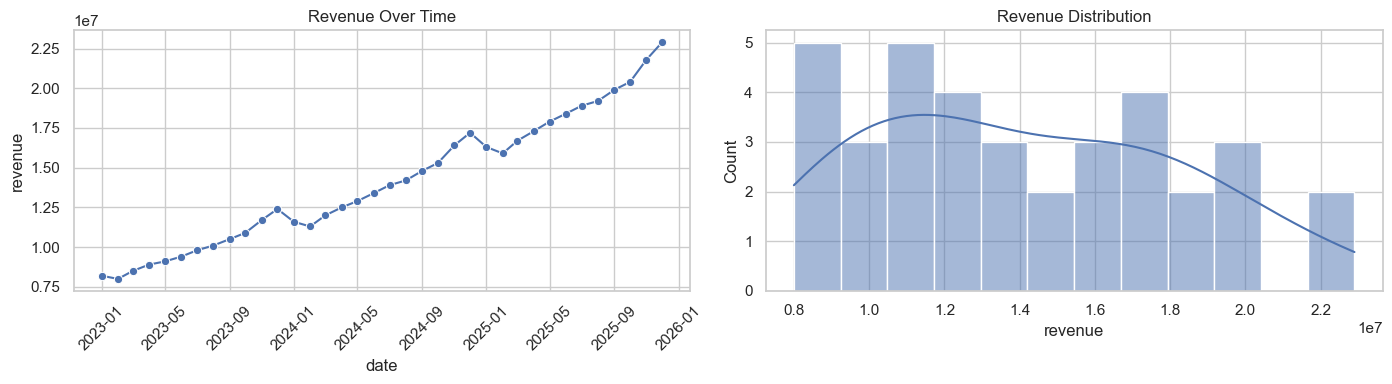

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=df, x=time_col, y=target_col, marker="o", ax=axes[0])
axes[0].set_title("Revenue Over Time")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(df[target_col], bins=12, kde=True, ax=axes[1])
axes[1].set_title("Revenue Distribution")

plt.tight_layout()
plt.show()

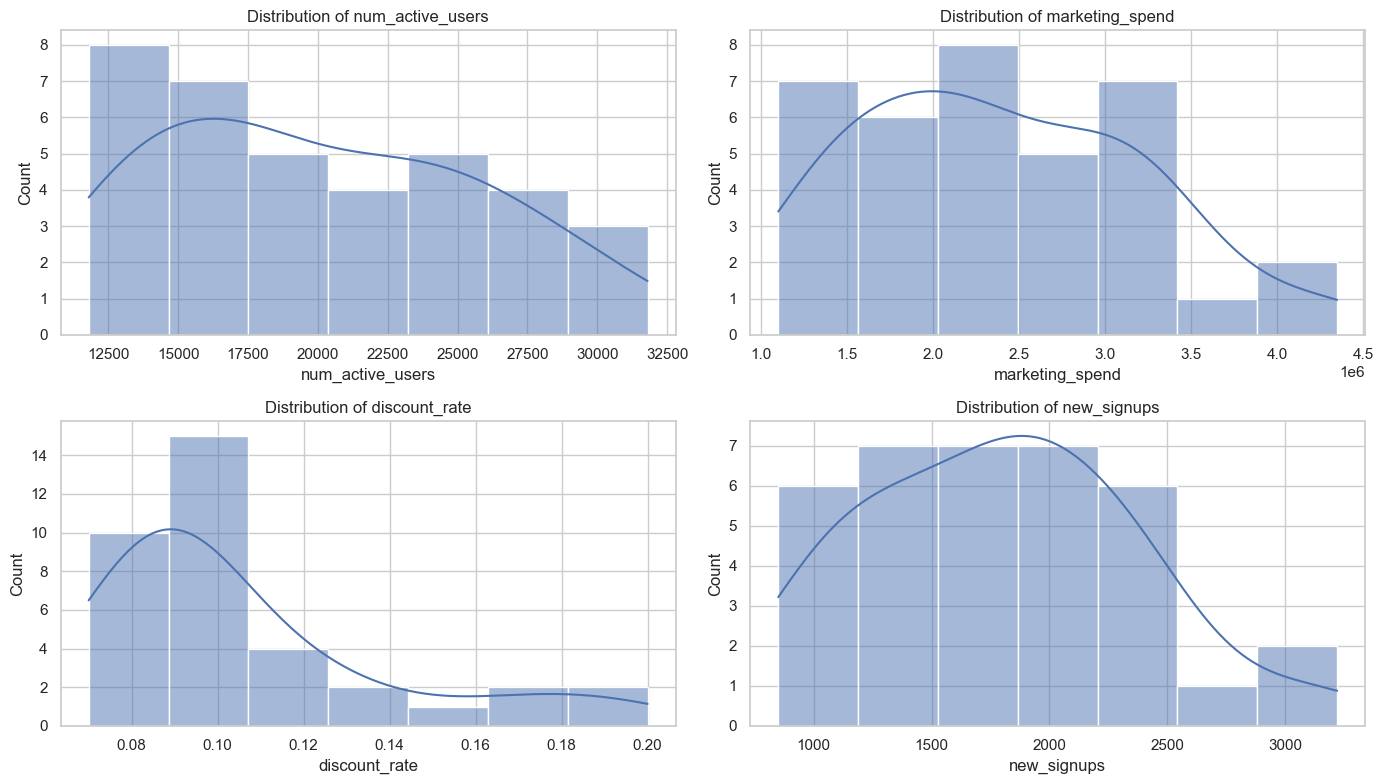

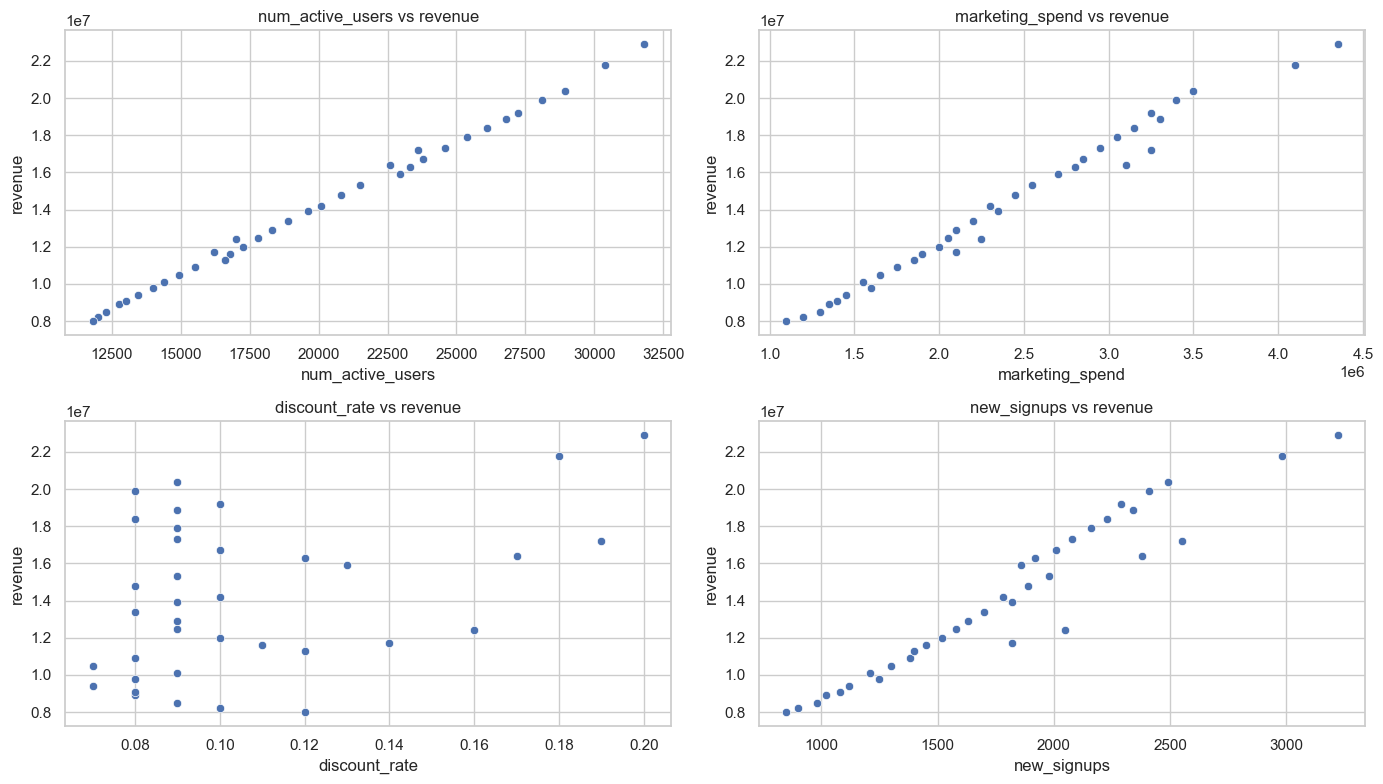

,revenue,num_active_users,marketing_spend,discount_rate,new_signups
revenue,1.000000,0.998831,0.991376,0.392909,0.960424
num_active_users,0.998831,1.000000,0.985496,0.368644,0.947377
marketing_spend,0.991376,0.985496,1.000000,0.492990,0.984480
discount_rate,0.392909,0.368644,0.492990,1.000000,0.568280
new_signups,0.960424,0.947377,0.984480,0.568280,1.000000


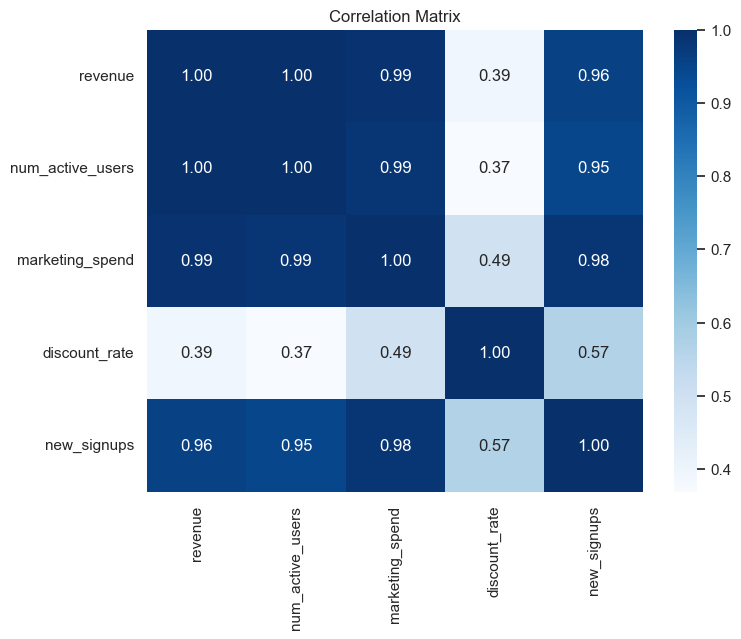

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.scatterplot(data=df, x=col, y=target_col, ax=ax)
    ax.set_title(f"{col} vs {target_col}")

plt.tight_layout()
plt.show()

corr = df[[target_col] + feature_cols].corr(numeric_only=True)
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Data Quality Notes and Additional Information Needed

- Confirm whether the upward trend is driven by business growth or pricing changes.
- Review months with relatively high `discount_rate` values.
- The dataset is short for forecasting, so validation may be unstable.
- Additional useful data: campaign calendar, churn volume, pricing history, and special events.
